In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split


def polynomial_features(X: np.ndarray, degree: int) -> np.ndarray:
    X = X.reshape(-1, 1)
    powers = np.arange(degree + 1)
    Phi = X ** powers
    return Phi

def simulate_polynomial_data(dtrue: int, w_true: np.ndarray, n: int, sigma2: float, a: float):
    rng = np.random
    X = rng.uniform(0, a, size=n)
    X = np.sort(X)
    y_true = np.zeros(n)
    for i in range(dtrue + 1):
        y_true += w_true[i] * X**i
    y = y_true + rng.normal(0, np.sqrt(sigma2), size=n)
    return X, y


def sgd_polynomial_track(Phi_train, y_train, Phi_val, y_val,
                              eta=1e-3, batch_size=20, max_iters=20000,
                              tol=1e-8, reg=None, lam=0.001, mode="best",
                              verbose=False, log_every=100):
    rng = np.random
    n_samples, n_features = Phi_train.shape
    w = rng.normal(0, 1, size=n_features)
    train_losses, val_losses = [], []
    best_val_loss = np.inf
    best_w = None

    for it in range(1, max_iters + 1):
        # Sample batch
        idx = rng.choice(n_samples, size=batch_size, replace=False)
        Xb, yb = Phi_train[idx], y_train[idx]

        # Gradient
        error = Xb @ w - yb
        grad = (Xb.T @ error) / batch_size

        # Regularization
        if reg == 'L2':
            grad[1:] += 2 * lam * w[1:]
        elif reg == 'L1':
            grad[1:] += lam * np.sign(w[1:])

        # SGD update
        w -= eta * grad

        # Compute loss periodically
        if it % log_every == 0 or it == 1:
            train_loss = np.mean((Phi_train @ w - y_train) ** 2)
            val_loss = np.mean((Phi_val @ w - y_val) ** 2)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if verbose:
                print(f"Iter {it}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

            if mode == "best" and val_loss < best_val_loss:
                best_val_loss = val_loss
                best_w = w.copy()

    
        if np.linalg.norm(eta * grad) < tol:
            if verbose:
                print(f"Converged at iteration {it}")
            break

    final_w = best_w if (mode == "best" and best_w is not None) else w
    return final_w, train_losses, val_losses


In [ ]:

dtrue = 5
w_true = np.array([1.0, 2.0, -3, 4, 2, -1])   # fixed length
n_total = 100
sigma2 = 30
a = 6

X_full, y_full = simulate_polynomial_data(dtrue, w_true, n_total, sigma2, a)
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

scaler_x = MinMaxScaler(feature_range=(-1, 1))
#scaler_x = StandardScaler()
scaler_y = StandardScaler().fit(y_full.reshape(-1, 1))
X_train_scaled = scaler_x.fit_transform(X_train.reshape(-1, 1)).ravel()   # ← .ravel()!
X_test_scaled  = scaler_x.transform(X_test.reshape(-1, 1)).ravel()        # ← .ravel()!
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()
y_train_scaled = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
fit_degree = 6
eta = 10e-7          # ← much larger learning rate works because we scaled x
max_iters = 200000
batch_size = 10

Phi_train = polynomial_features(X_train_scaled, fit_degree)
Phi_test  = polynomial_features(X_test_scaled,  fit_degree)


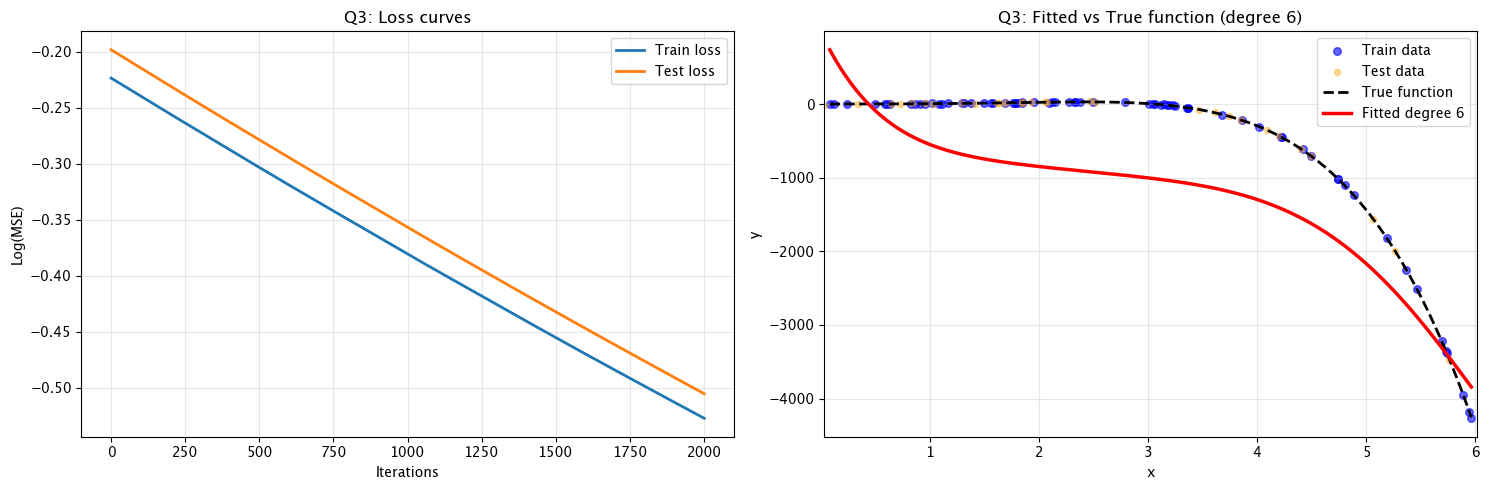

[-0.54035499 -0.510999   -0.50588269 -1.18813011 -1.11798573 -0.54006354
  1.09026611]
Final train MSE: 0.5901608462803704
Final test MSE : 0.6032575061628273


In [440]:

w_fit, train_loss_hist, val_loss_hist = sgd_polynomial_track(
    Phi_train, y_train_scaled, Phi_test, y_test_scaled,
    eta=eta, batch_size=batch_size, max_iters=max_iters, mode="best"
)

# Dense x values for plotting
x_dense_raw = np.linspace(X_train.min(), X_train.max(), 500).reshape(-1, 1)

# Scale for the model
x_dense_scaled = scaler_x.transform(x_dense_raw)  # keep 2D

# Polynomial features
Phi_dense_fit = polynomial_features(x_dense_scaled.ravel(), fit_degree)  # scaled for model
y_fit_dense = scaler_y.inverse_transform((Phi_dense_fit @ w_fit).reshape(-1,1))

Phi_dense_true = polynomial_features(x_dense_raw.ravel(), dtrue)       # raw for true function
y_true_dense = Phi_dense_true @ w_true



fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
# Loss curves
axs[0].plot(np.log(train_loss_hist), label='Train loss', lw=2)
axs[0].plot(np.log(val_loss_hist), label='Test loss', lw=2)
axs[0].set_title('Q3: Loss curves')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Log(MSE)')
axs[0].legend()
axs[0].grid(alpha=0.3)

# Data + fits
axs[1].scatter(X_train, y_train, color='blue', alpha=0.6, s=30, label='Train data')
axs[1].scatter(X_test, y_test, color='orange', alpha=0.4, s=20, label='Test data')
axs[1].plot(x_dense_raw, y_true_dense, 'k--', lw=2, label='True function')
axs[1].plot(x_dense_raw, y_fit_dense, 'red', lw=2.5, label=f'Fitted degree {fit_degree}')
axs[1].set_xlim(X_train.min() - 0.05, X_train.max() + 0.05)
axs[1].set_title(f'Q3: Fitted vs True function (degree {fit_degree})')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].legend()
axs[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()
fig.savefig("q3_fitted_curves.svg", format="svg")
fig.savefig("q3_fitted_curves.png", format="png")
print(w_fit)
print("Final train MSE:", train_loss_hist[-1])
print("Final test MSE :", val_loss_hist[-1])


--- Q4 Results ---
d_model= 1 | Train MSE: 0.5572 | Test MSE: 0.7840 | Weights : [0.5279 0.7868]
d_model= 3 | Train MSE: 0.1498 | Test MSE: 1.2501 | Weights : [ 0.2423 -1.3311  0.8367  2.3858]
d_model= 5 | Train MSE: 0.1256 | Test MSE: 1.9190 | Weights : [ 0.1991 -0.0552 -0.0336 -1.3758  0.9687  2.5385]
d_model= 8 | Train MSE: 0.1099 | Test MSE: 8.7864 | Weights : [ 0.1479 -0.4753  0.5727  0.2417  0.7111 -0.5857  0.5819  2.0068 -0.9957]
d_model=12 | Train MSE: 0.1056 | Test MSE: 15.5402 | Weights : [ 0.1402 -0.5455  0.8883  0.2063  0.2973  0.1768  0.4679  0.6661 -0.9764
 -0.3858 -0.4165  1.1176  0.6353]
d_model=20 | Train MSE: 0.0945 | Test MSE: 397.3387 | Weights : [-0.0679  0.4447  1.0562 -1.0237 -0.1425 -0.7989  0.473   1.5502  0.4545
  0.3693 -0.5627 -0.501  -0.0952  0.2855 -0.654  -0.276   0.3254  0.9587
  0.0784  0.2937  0.217 ]


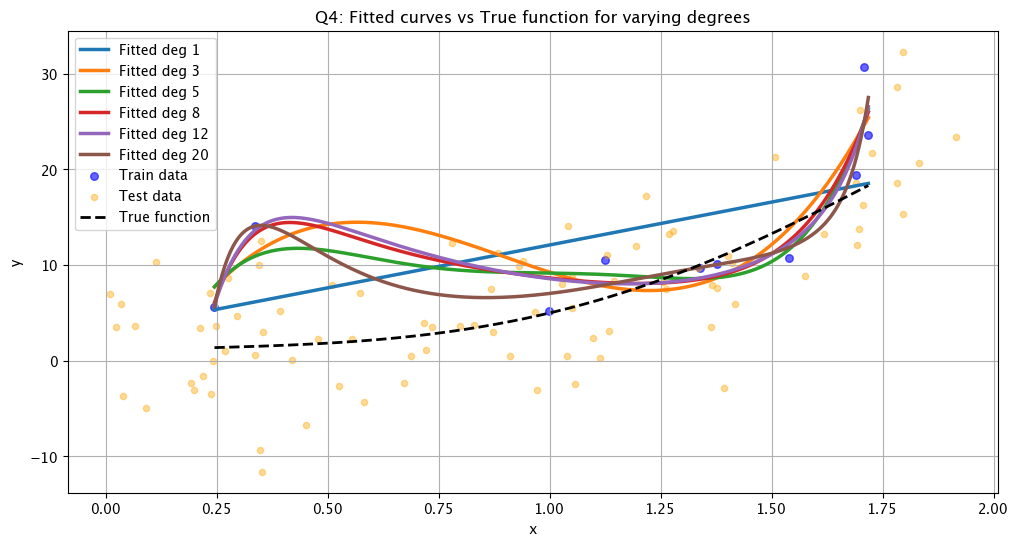

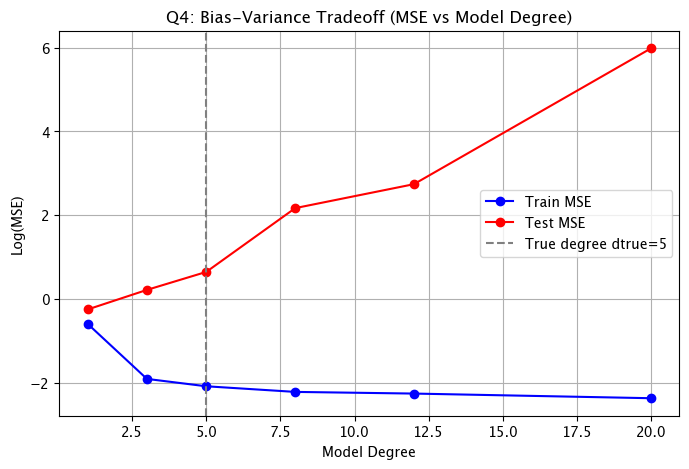

In [417]:
print(f"\n--- Q4 Results ---")

d_models = [1, 3, 5, 8, 12, 20]  # Vary model degree
train_errors_q4 = []
test_errors_q4 = []

# Dense x values for plotting fitted curves
x_dense_raw = np.linspace(X_train.min(), X_train.max(), 500).reshape(-1, 1)

# Create figure and axes **before the loop**
fig1, ax1 = plt.subplots(figsize=(12, 6))

for d_model in d_models:
    # Generate polynomial features
    Phi_train = polynomial_features(X_train_scaled, d_model)
    Phi_test  = polynomial_features(X_test_scaled,  d_model)

    # Train model
    w_model, _, _ = sgd_polynomial_track(
        Phi_train, y_train_scaled, Phi_test, y_test_scaled,
        eta=eta, batch_size=batch_size, max_iters=200000, mode="last"
    )

    # Compute MSE
    y_pred_train = Phi_train @ w_model
    y_pred_test  = Phi_test  @ w_model
    train_mse = np.mean((y_pred_train - y_train_scaled)**2)
    test_mse  = np.mean((y_pred_test  - y_test_scaled)**2)
    train_errors_q4.append(train_mse)
    test_errors_q4.append(test_mse)

    print(f"d_model={d_model:2d} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f} | Weights : {np.round(w_model, 4)}")

    # Plot fitted curve on ax1
    Phi_dense_fit = polynomial_features(x_dense_scaled.ravel(), d_model)
    y_fit_dense = scaler_y.inverse_transform((Phi_dense_fit @ w_model).reshape(-1, 1))
    ax1.plot(x_dense_raw, y_fit_dense, lw=2.5, label=f'Fitted deg {d_model}')

# Plot data and true function
y_true_dense = polynomial_features(x_dense_raw.ravel(), dtrue) @ w_true
ax1.scatter(X_train, y_train, color='blue', alpha=0.6, s=30, label='Train data')
ax1.scatter(X_test,  y_test,  color='orange', alpha=0.4, s=20, label='Test data')
ax1.plot(x_dense_raw, y_true_dense, 'k--', lw=2, label='True function')

# Labels, title, legend
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Q4: Fitted curves vs True function for varying degrees')
ax1.legend()
ax1.grid(True)

# Save SVG **before show**
fig1.savefig("q4_fitted_curves.svg", format="svg")
fig1.savefig("q4_fitted_curves.png", format="png")
plt.show()


# --- Second plot: train/test MSE vs model degree ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
train_errors_q4 = np.array(train_errors_q4)
test_errors_q4  = np.array(test_errors_q4)
eps = 1e-12  # prevent log(0)

ax2.plot(d_models, np.log(train_errors_q4 + eps), 'o-', label='Train MSE', color='blue')
ax2.plot(d_models, np.log(test_errors_q4 + eps), 'o-', label='Test MSE',  color='red')
ax2.axvline(x=dtrue, color='gray', linestyle='--', label=f'True degree dtrue={dtrue}')

ax2.set_xlabel('Model Degree')
ax2.set_ylabel('Log(MSE)')
ax2.set_title('Q4: Bias-Variance Tradeoff (MSE vs Model Degree)')
ax2.legend()
ax2.grid(True)

fig2.savefig("q4_BV.svg", format="svg")
fig2.savefig("q4_BV.spng", format="png")
plt.show()
